# Model speed up with factor s: origin and application

## Origin

### Perturbation lifetime $\tau$

In a quasi-steady state with a trace gas mass change X [kg], an annual emission E [kg/year} and a perturbation lifetime $\tau$ [years] the following relation applies

$0 = \frac{\delta X}{\delta t} = E - \frac{1}{\tau}X$

Which is in another presentation

$X = \tau E$

### Factor s

To obtain the value of s we solve the differential equation for the evolution of the stratospheric water vapour mass Y for an emission sX

$\frac{\delta Y}{\delta t} = sE - \frac{1}{\tau} Y$

Using boundary conditions $Y(t=0) = 0$ and $Y(t=1)=\tau E$. The solution of the differential equation, that fulfills the first boundary condition is then

$Y(t) = s \tau E ~ (1 - e^{-\frac{1}{\tau}t})$

In combination with the second boundary condition this gives us

$s=\frac{1}{1-e^{-\frac{1}{\tau}}}$

Hence, if we estimate s with a Taylor approximation we obtain the perturbation lifetime of 𝜏. However, if we enhance the emission by this factor $\tau$, we additionally have to consider the loss during the first year with a factor of 0.5, which applies for $\tau$ between 2 to 5 years.

$s \approx 𝜏 + 0.5$

## Application

### Import modules

In [1]:
import numpy as np
from scipy.interpolate import interp1d

In [2]:
import matplotlib.pyplot as plt

### Altitudes x and perturbation lifetimes y from simulations

In [3]:
x = [16,20,26,35] # [km]
y = [8/12,2,3.5,4.6] # [years]

The lower two and upper two values originate from water vapour perturbation lifetimes publised in Grewe & Stenke (2008) and Pletzer 2022 (in prep.), respectively. 

### Functions for interpolation and extrapolation

In [4]:
f_il = interp1d(x, y,kind='linear')
f_iq = interp1d(x, y,kind='quadratic')

In [5]:
f_el = interp1d(x, y, fill_value='extrapolate', kind='linear')
f_eq = interp1d(x, y, fill_value='extrapolate', kind='quadratic')

### Linear estimate

In [6]:
x_x = np.arange(15,44,2)

In [7]:
func_extrap_lin = f_el(x_x)

### Quadratic estimate

In [8]:
func_extrap_quad = f_eq(x_x)

### Average of linear and quadratic estimate

In [9]:
y_ave = [( f_eq(30) + f_el(30) ) / 2,( f_eq(38) + f_el(38) ) / 2]

### Visualize results

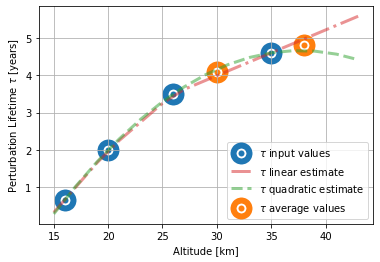

In [10]:
plt.figure()

# Plot input data with blue circles
plt.scatter(x, y, lw=16, color='tab:blue', alpha = 1., label=r'$\tau$' + ' input values')

# Plot linear and quadratic estimate lines
plt.plot(x_x, func_extrap_lin, '-.', color='tab:red', lw=3, alpha=0.5, label=r'$\tau$' + ' linear estimate')
plt.plot(x_x, func_extrap_quad, '--', color='tab:green', lw=3, alpha=0.5, label=r'$\tau$' + ' quadratic estimate')

# Plot calculated data
plt.scatter([30,38], y_ave, lw=16, color='tab:orange', alpha=1., label=r'$\tau$' + ' average values')

# Labels and other plt settings 
plt.ylabel('Perturbation Lifetime ' + r'$\tau$ [years]')
plt.xlabel('Altitude [km]')
plt.legend()
plt.grid()

plt.show()

## Factor s

In this example s is calculated for 30 and 38 km as an average of the linear and quadratic estimate. In most cases between 15-35 km the linear estimate is close to the quadratic estimate and the linear estimate should be sufficient.

In [11]:
s_30km = ( f_eq(30) + f_el(30) ) / 2 + 0.5

In [12]:
round(s_30km, 2)

4.57

In [13]:
s_38km = ( f_eq(38) + f_el(38) ) / 2 + 0.5

In [14]:
round(s_38km, 2)

5.31

## How to proceed

- For the model speed up the factor s has to be applied to the model input (aircraft emissions) in the first year only. Either in the namelist file or directly in the model input, i.e. emission data.

- After the first year the model input has to be reset to the original model input. 

- Transport times for the trace gas families, e.g. NO emission --> NOy perturbations or H$_2$O, H$_2$ emissions --> HOx perturbations, are assumed to be equal and the factor s is applied to all of them.

Beware that depending on the scenario the application can be less or more complex. E.g. if the emissions are distributed at different altitudes the factor s has to be applied for each altitude accordingly.